# Анализ оттока клиентов (Churn Prediction)

**BI-проект:** Исследование причин оттока, когортный анализ, LTV, предсказательная модель и рекомендации по удержанию.

Цель — помочь компании снизить отток клиентов и повысить удержание.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

print("Библиотеки загружены!")

Библиотеки загружены!


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Размер датасета:", df.shape)
df.head()

Размер датасета: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Преобразование типов
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Churn в 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Данные после предобработки:")
print(df.isnull().sum().sum())  # должно быть 0

Данные после предобработки:
0


## 1. Exploratory Data Analysis (EDA)

In [4]:
print("Общая доля оттока:", round(df['Churn'].mean() * 100, 2), "%\n")

print("Отток по полу:")
print(df.groupby('gender')['Churn'].mean().round(3))

print("\nОтток по SeniorCitizen:")
print(df.groupby('SeniorCitizen')['Churn'].mean().round(3))

print("\nОтток по наличию партнёра:")
print(df.groupby('Partner')['Churn'].mean().round(3))

print("\nОтток по типу контракта:")
print(df.groupby('Contract')['Churn'].mean().round(3))

Общая доля оттока: 26.54 %

Отток по полу:
gender
Female    0.269
Male      0.262
Name: Churn, dtype: float64

Отток по SeniorCitizen:
SeniorCitizen
0    0.236
1    0.417
Name: Churn, dtype: float64

Отток по наличию партнёра:
Partner
No     0.330
Yes    0.197
Name: Churn, dtype: float64

Отток по типу контракта:
Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn, dtype: float64


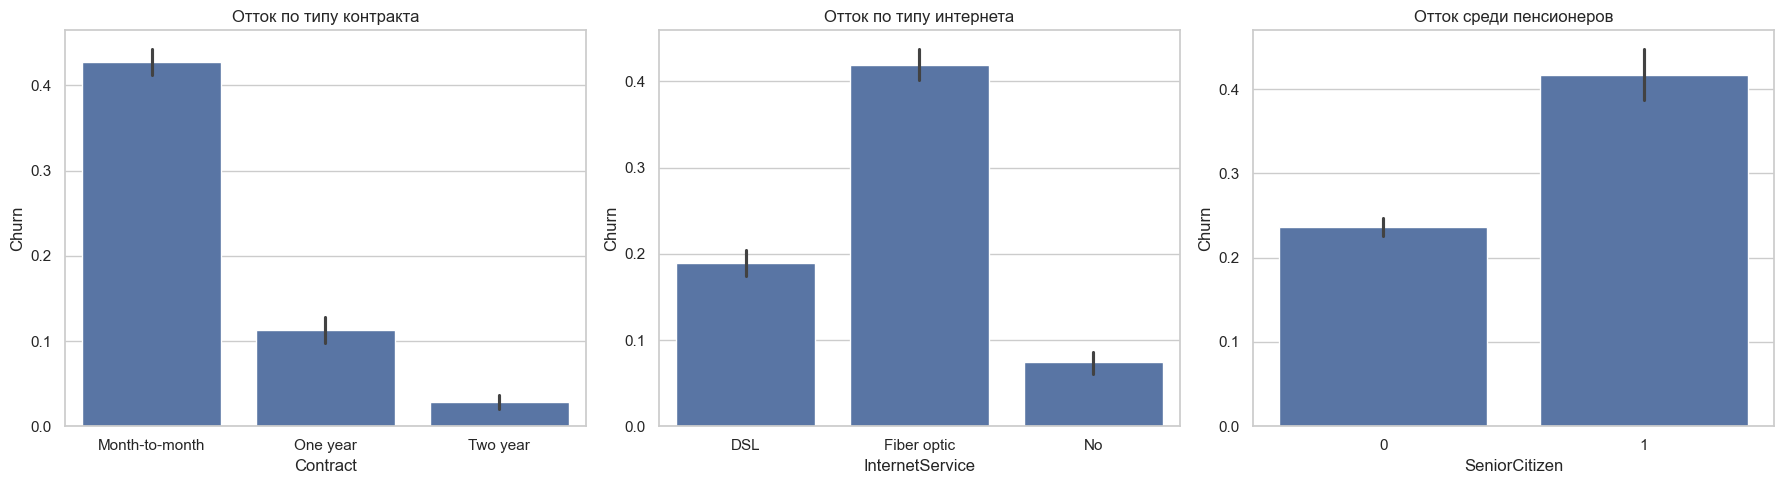

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='Contract', y='Churn', data=df, ax=axes[0])
axes[0].set_title('Отток по типу контракта')

sns.barplot(x='InternetService', y='Churn', data=df, ax=axes[1])
axes[1].set_title('Отток по типу интернета')

sns.barplot(x='SeniorCitizen', y='Churn', data=df, ax=axes[2])
axes[2].set_title('Отток среди пенсионеров')

plt.tight_layout()
plt.show()

## 2. Когортный анализ и Retention

In [6]:
# Создаём когорту по месяцу начала (tenure)
df['Cohort'] = (df['tenure'] // 6) * 6   # группируем по 6 месяцев

cohort = df.groupby(['Cohort', 'tenure'])['customerID'].count().unstack(0)

# Retention rate
retention = cohort.div(cohort.iloc[0], axis=1)

print("Retention по когортам (первые 12 месяцев):")
print(retention.head(13))

Retention по когортам (первые 12 месяцев):
Cohort         0   6   12  18  24  30  36  42  48  54  60  66  72
tenure                                                           
0        1.000000 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
1       55.727273 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
2       21.636364 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
3       18.181818 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
4       16.000000 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
5       12.090909 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
6             NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
7             NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
8             NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
9             NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
10            NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
11            NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN
12            NaN NaN NaN NaN NaN

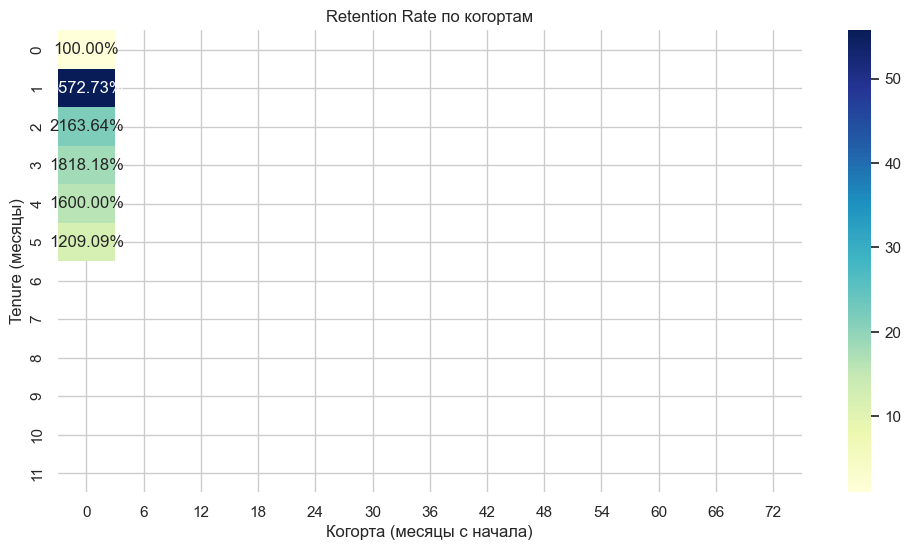

In [7]:
plt.figure(figsize=(12, 6))
sns.heatmap(retention.head(12), annot=True, fmt='.2%', cmap='YlGnBu')
plt.title('Retention Rate по когортам')
plt.ylabel('Tenure (месяцы)')
plt.xlabel('Когорта (месяцы с начала)')
plt.show()

## 3. Расчёт LTV (Lifetime Value)

In [8]:
# Простой LTV = MonthlyCharges * tenure (для ушедших) + прогноз для активных
df['LTV'] = df['MonthlyCharges'] * df['tenure']

print("Средний LTV:")
print("Общий:", round(df['LTV'].mean(), 2))
print("У оттока:", round(df[df['Churn'] == 1]['LTV'].mean(), 2))
print("У активных:", round(df[df['Churn'] == 0]['LTV'].mean(), 2))

Средний LTV:
Общий: 2279.58
У оттока: 1531.61
У активных: 2549.77


## 4. A/B-тестирование гипотез

In [9]:
# Сравниваем отток по разным группам
ab_test = df.groupby(['Contract', 'InternetService']).agg({
    'Churn': ['mean', 'count']
}).round(3)

print("A/B-тест: Отток по типу контракта и интернету")
print(ab_test)

A/B-тест: Отток по типу контракта и интернету
                                Churn      
                                 mean count
Contract       InternetService             
Month-to-month DSL              0.322  1223
               Fiber optic      0.546  2128
               No               0.189   524
One year       DSL              0.093   570
               Fiber optic      0.193   539
               No               0.025   364
Two year       DSL              0.019   628
               Fiber optic      0.072   429
               No               0.008   638


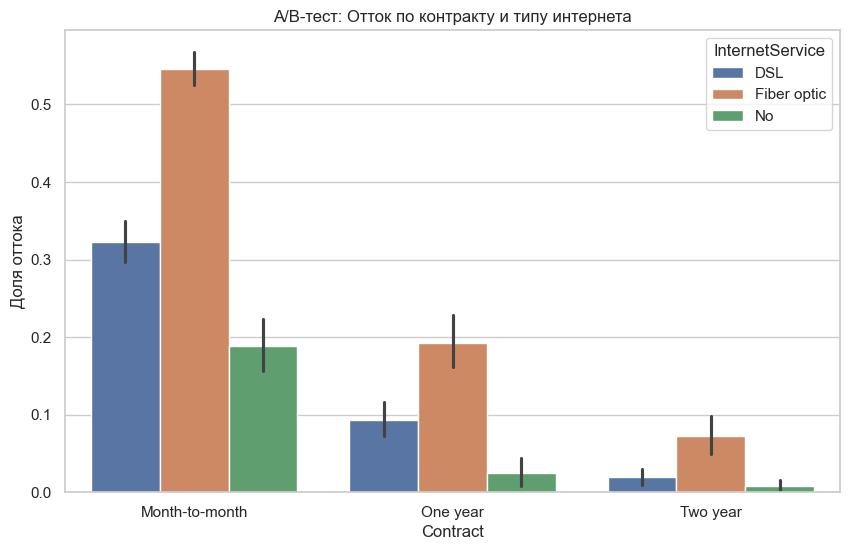

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Contract', y='Churn', hue='InternetService', data=df)
plt.title('A/B-тест: Отток по контракту и типу интернета')
plt.ylabel('Доля оттока')
plt.show()

## 5. Бизнес-рекомендации

1. **Тип контракта** — клиенты на Month-to-month уходят значительно чаще. Нужно стимулировать переход на годовые/двухлетние контракты (скидки, бонусы).

2. **Интернет-сервис** — Fiber optic имеет самый высокий отток. Проверить качество услуги.

3. **SeniorCitizen** — пенсионеры уходят чаще — нужна специальная программа лояльности.

4. **LTV** — активные клиенты имеют значительно выше LTV. Фокус на удержании.

5. **Действия**:
   - Внедрить программу удержания для клиентов с высоким риском оттока
   - Предлагать скидки на годовые контракты
   - Улучшить качество Fiber optic

## 6. Построение модели предсказания оттока

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Выбираем признаки
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 
            'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

# Преобразуем категориальные в dummy
X = pd.get_dummies(df[features], drop_first=True)
y = df['Churn']

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Данные подготовлены для модели.")

Данные подготовлены для модели.


In [12]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Предсказание
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 79.89 %

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1539
           1       0.68      0.49      0.57       574

    accuracy                           0.80      2113
   macro avg       0.75      0.70      0.72      2113
weighted avg       0.79      0.80      0.79      2113



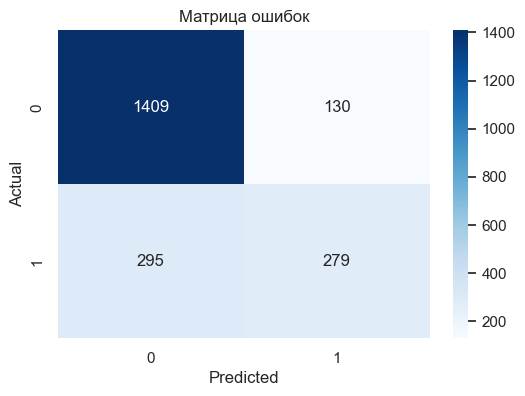

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Итоговые выводы и рекомендации

Проект показал:
- Высокий отток на ежемесячных контрактах
- Fiber optic — зона риска
- Модель предсказания оттока готова к использованию

**Рекомендации:**
- Стимулировать долгосрочные контракты
- Улучшить качество Fiber optic
- Внедрить систему раннего предупреждения оттока